# Python 2DAlphabet ABCDEF Demo

Runs the pure-Python pass/fail fitter in `python/twodalphabet_py.py` on real
`mtt_vs_mt` coffea histograms stored in `outputs/2dalphabet_inputs/hists_{year}.pkl`
(produced by `make2dalphabet.ipynb`).

In [38]:
import pickle
import importlib
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
sys.path.insert(0, str(repo / "python"))

import twodalphabet_py
twodalphabet_py = importlib.reload(twodalphabet_py)
from twodalphabet_py import Hist2D, PassFailModelInput, FormulaTransferFunction, PassFail2DFitter

year = "2024"
with open(repo / "outputs" / "2dalphabet_inputs" / f"hists_{year}.pkl", "rb") as f:
    hists = pickle.load(f)

## Build inputs

In [39]:
ANCAT = {"atcen": 0, "atfwd": 1, "2tcen": 2, "2tfwd": 3}

h_data  = hists["data"]
h_ttbar = hists["ttbar"]

inputs = PassFailModelInput(
    data_fail=Hist2D.from_hist(h_data[{"anacat": ANCAT["atcen"], "systematic": "nominal"}]),
    data_pass=Hist2D.from_hist(h_data[{"anacat": ANCAT["2tcen"], "systematic": "nominal"}]),
    bkg_fail=Hist2D.from_hist(h_ttbar[{"anacat": ANCAT["atcen"], "systematic": "nominal"}]),
    bkg_pass=Hist2D.from_hist(h_ttbar[{"anacat": ANCAT["2tcen"], "systematic": "nominal"}]),
)

# bin edges for plotting (from the fail slice; same grid for all)
h_ref    = h_data[{"anacat": ANCAT["atcen"], "systematic": "nominal"}]
x_edges  = h_ref.axes[0].edges   # jet mass
y_edges  = h_ref.axes[1].edges   # m_tt

## Fit the ABCDEF 2DAlphabet Core Model

This uses the same core algebra as 2DAlphabet/Combine with the standard blinded ABCDEF layout. The pass signal window `D` is excluded from the likelihood, but the fitted model still predicts it. Coordinates `x` and `y` are bin centers mapped to `[0, 1]`, matching `TwoDAlphabet.alphawrap.ParametricFunction`.

## ABCDEF Region Map

The Python fitter now uses the same six-region sideband idea as the 2DAlphabet setup. The X axis is the top-candidate jet mass (`mt`/`jetmass`); the Y axis is `m_tt`.

```text
                       top-candidate mass axis (mt / jetmass)
                 25-105 GeV       105-210 GeV       210-475 GeV
              +---------------+----------------+----------------+
 FAIL / at    |       A       |       C        |       E        |
              | fail LOW      | fail SIG       | fail HIGH      |
              +---------------+----------------+----------------+
 PASS / 2t    |       B       |       D        |       F        |
              | pass LOW      | pass SIG       | pass HIGH      |
              +---------------+----------------+----------------+

D = blinded pass signal window in the background-only fit.
C remains included: qcd_D is predicted from qcd_C * Rpf(mt, mtt).
B and F constrain the pass/fail transfer function in sidebands.
A, C, and E anchor the free fail-region QCD bin parameters.
```

In code terms:

```text
qcd_fail[x, y] = free positive bin parameter
qcd_pass[x, y] = qcd_fail[x, y] * Rpf(x, y; theta)
fit bins = A + B + C + E + F
blinded prediction = D
```

In [40]:
sig_start, sig_end = 105.0, 210.0   # jet mass signal window [GeV]

tf = FormulaTransferFunction(
    "@0+@1*x+@2*y",
    {
        0: {"NOM": 1.5, "MIN": 0.0,  "MAX": 20.0, "ERROR": 0.2},
        1: {"NOM": 0.0, "MIN": -10.0, "MAX": 10.0, "ERROR": 0.2},
        2: {"NOM": 0.0, "MIN": -10.0, "MAX": 10.0, "ERROR": 0.2},
    },
)

fitter = PassFail2DFitter.abcdef(inputs, tf, sig_start=sig_start, sig_end=sig_end, blind_pass_signal=True)
fit = fitter.fit(options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8})

print("success:", fit.success)
print("message:", fit.message)
print("nll:    ", fit.nll)
print("params: ", fit.params)

success: True
message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
nll:     -41549.806540240264
params:  {'rpf_par0': 0.6663799275287853, 'rpf_par1': -0.1852462052179125, 'rpf_par2': 0.803193026002224}


In [41]:
print("ABCDEF yields:")
for source, yields in fit.abcdef_yields.items():
    print(f"  {source}:", ", ".join(f"{r}={v:.1f}" for r, v in yields.items()))

ABCDEF yields:
  data: A=7301.0, B=6556.0, C=3316.0, D=7726.0, E=937.0, F=1465.0
  qcd: A=6964.0, B=4975.7, C=2093.5, D=1412.3, E=708.7, F=461.8
  expected: A=7289.0, B=6680.7, C=3352.0, D=11336.1, E=946.2, F=1770.1


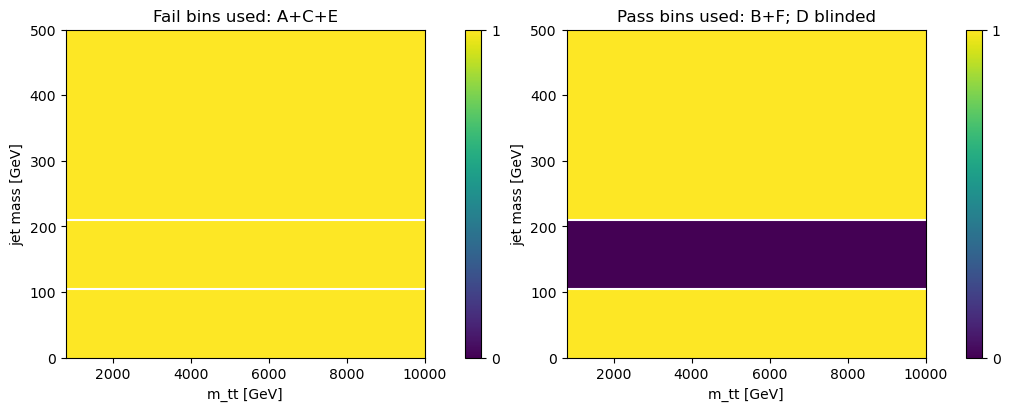

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, mask, title in [
    (axes[0], fit.fail_fit_mask, "Fail bins used: A+C+E"),
    (axes[1], fit.pass_fit_mask, "Pass bins used: B+F; D blinded"),
]:
    mesh = ax.pcolormesh(y_edges, x_edges, mask.astype(int), shading="auto", vmin=0, vmax=1)
    ax.axhline(sig_start, color="white", linewidth=1.5)
    ax.axhline(sig_end,   color="white", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("jet mass [GeV]")
    fig.colorbar(mesh, ax=ax, ticks=[0, 1])
plt.show()

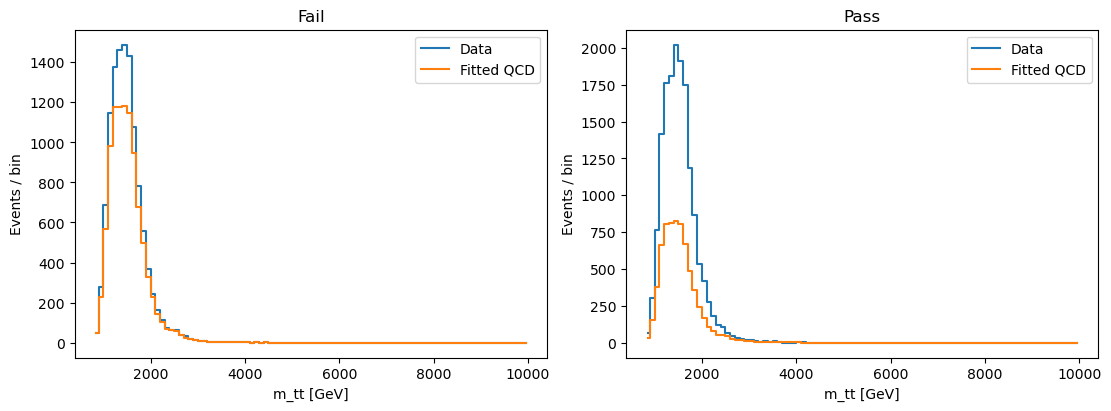

In [43]:
mtt_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

fig, (ax_fail, ax_pass) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, data_2d, qcd_2d, title in [
    (ax_fail, inputs.data_fail.values, fit.qcd_fail, "Fail"),
    (ax_pass, inputs.data_pass.values, fit.qcd_pass, "Pass"),
]:
    ax.step(mtt_centers, data_2d.sum(axis=0), where="mid", label="Data")
    ax.step(mtt_centers, qcd_2d.sum(axis=0),  where="mid", label="Fitted QCD")
    ax.set_xlabel("m_tt [GeV]")
    ax.set_ylabel("Events / bin")
    ax.set_title(title)
    ax.legend()
plt.show()